In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram,linkage
from sklearn.cluster import KMeans,AgglomerativeClustering

## **Mall Customer Segmentation System**

### Section - A (K-Means Clustering)

In [2]:
# Loading The Dataset
df = pd.read_csv("Mall_Customers_Dataset.csv")
df

,CustomerID,Genre,Age,Annual_Income_kUSD,Spending_Score,Purchase_Freq,Recency_days
0,1,Male,19,15,39,11,29
1,2,Male,21,15,81,1,71
2,3,Female,20,16,6,4,58
3,4,Female,23,16,77,3,27
4,5,Female,31,17,40,11,140
...,...,...,...,...,...,...,...
195,196,Female,25,91,55,5,12
196,197,Male,29,92,41,1,86
197,198,Female,26,92,55,3,68
198,199,Male,28,99,39,3,114


- From The Above Dataset You Can See That There Are Columns Which Contains Customer Information Collected From A Shopping Mall : "Cusomer_Id","Age","Genre","Annual Income","And Purchase Frequency".

- The Dataset Is Used For Clustering , Dimensionality Reduction, Anomaly Detection, And Recommendation System.

#### Q1

In [28]:
# Selecting Features 
x_kmeans = df[["Annual_Income_kUSD","Spending_Score"]]

- Income Tells The Purchasing Power
- Spending Score Tells Customer Behaviour

In [29]:
# Standardizing The Features Through Pipeline To Prevent Data Leakeage
preprocessing_pipeline = Pipeline([
    ("StandardScaler",StandardScaler())
])

preprocessing = ColumnTransformer([
    ("Preprocessing",preprocessing_pipeline,["Annual_Income_kUSD","Spending_Score"])
])

- Preprocessing The Data To Prevent Wrong Prediction Of Data Points Because Unusual High Values.

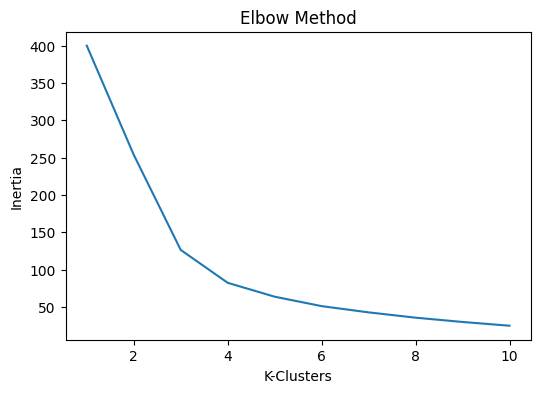

In [ ]:
# Applying Elbow Method By Building A Pipeline
inertia = []
for i in range(1,11):
    inertia_model = Pipeline([
        ("preprocessing",preprocessing),
        ("algorithm",KMeans(n_clusters=i,random_state=42,n_init=10))
    ])
    inertia_model.fit(x_kmeans)
    inertia.append(inertia_model["algorithm"].inertia_)

# Ploting The Inertia Graph
plt.figure(figsize=(6,4))
plt.plot(range(1,11),inertia)
plt.title("Elbow Method")
plt.xlabel("K-Clusters")
plt.ylabel("Inertia")
plt.show()

- We Have Calculated Inertia Using Elbow Method. Now We Can See That In The Above Graph When The Line Starting Curving That Is The Point Of Cluster We Can Select For Prediction.

In [45]:
# Find The Sihouette Score Of Each Cluster And Show The Best Score
scores = []
for i in range(2,9):
    silhouette_pipeline = Pipeline([
        ("preprocessing",preprocessing),
        ("algorithm",KMeans(n_clusters=i,random_state=42,n_init=10))
    ])
    labels = silhouette_pipeline.fit_predict(x_kmeans)
    score = silhouette_score((silhouette_pipeline["preprocessing"].transform(x_kmeans)),labels)
    scores.append(score)

# Showing The Highest Silhouette Score With The K-Value
best_k = range(2,9)[scores.index(max(scores))]
print(f"The K-Value {best_k} With The Silhouette Score Of {max(scores)} Has The Highest Score")

The K-Value 3 With The Silhouette Score Of 0.5722631382572394 Has The Highest Score


- From The Above It Can Be Determined That With K-Value 3 THe Silhouette Score Is The Highest So Limited Number Are More Efficient Than more Number Of Clusters.

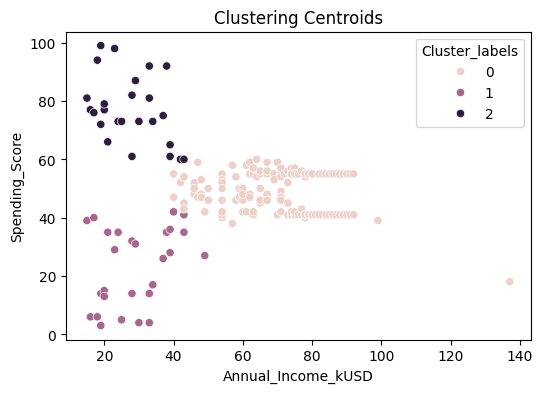

In [44]:
# Building The Final KMeans Model For Prediction With k=4
model_kmeans = Pipeline([
    ("preprocessing",preprocessing),
    ("algorithm",KMeans(n_clusters=3,random_state=42,n_init=10))
])
df["Cluster_labels"] = model_kmeans.fit_predict(x_kmeans)

# Ploting The Clusters With Centroids
plt.figure(figsize=(6,4))
sns.scatterplot(data=df,x="Annual_Income_kUSD",y="Spending_Score",hue="Cluster_labels")
plt.title("Clustering Centroids")
plt.show()

#### Q2

### Section - B (Hierarchical Clustering & DBSCAN)

#### Q3

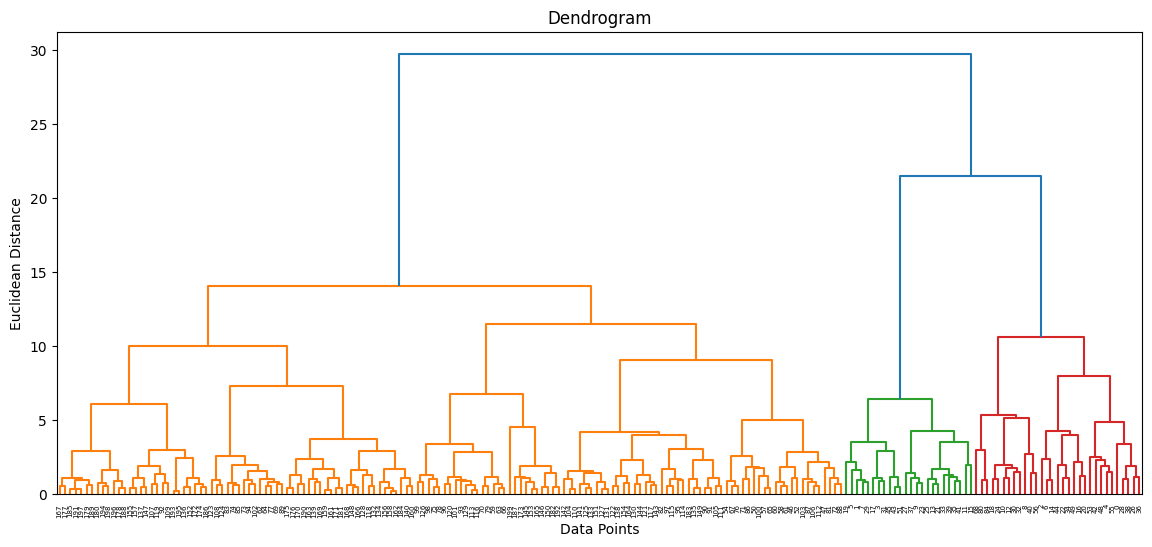

In [54]:
# Applying Agglomerative Hierarchical Clustering On All Numeric Features
numeric_df = df.select_dtypes(include="number")

# Applying Standard Scalar On This Features
numeric_scaled = StandardScaler().fit_transform(numeric_df)

# Computing Ward Linkage Matrix
linkage_matrix = linkage(numeric_scaled,method="ward")

# Plotting The Dendogram
plt.figure(figsize=(14,6))
dendrogram(linkage_matrix)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

- An Tree Based Structered Is Made In The Dendogram Because From Bottom Each Data Point Was Its Own Cluster But Eventually Linkage Method Measures Distance Between Clusters And Minimizes Variance.

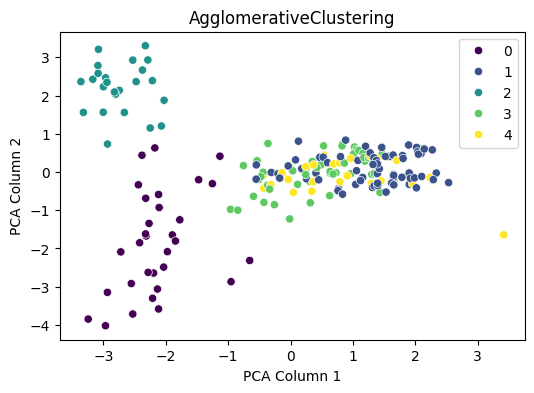

In [68]:
# Cuting The Dendogram And Fitting it To The Agglomerative Model For Prediction
model_agglo = Pipeline([
    ("algorithm",AgglomerativeClustering(n_clusters=5,linkage="ward",metric="euclidean"))
])
agglo_labels = model_agglo.fit_predict(numeric_scaled)

# Performing The PCA To Visualize The Agglo Model
pca = PCA(n_components=2)
x_pca = pca.fit_transform(numeric_scaled)

# Fitting The KMeans Model For Comparison
model_kmeans1 = Pipeline([
    ("algorithm",KMeans(n_clusters=3,random_state=42,n_init=10))
])
kmeans_labels = model_kmeans1.fit_predict(numeric_scaled)

# Ploting The Clusters Of Agglomerative Clustering
plt.figure(figsize=(6,4))
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],hue=agglo_labels,palette="viridis")
plt.xlabel("PCA Column 1")
plt.ylabel("PCA Column 2")
plt.title("AgglomerativeClustering")
plt.show()

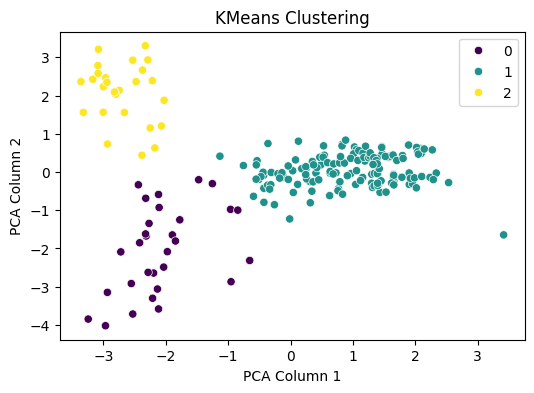

In [70]:
# Ploting The Clusters Of 
plt.figure(figsize=(6,4))
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],hue=kmeans_labels,palette="viridis")
plt.xlabel("PCA Column 1")
plt.ylabel("PCA Column 2")
plt.title("KMeans Clustering")
plt.show()

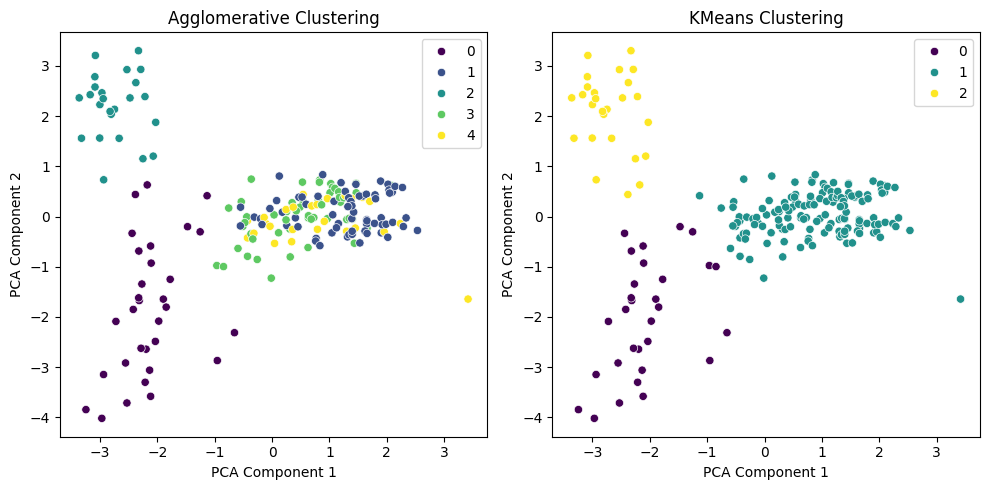

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Agglomerative Clustering Plot
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],hue=agglo_labels,palette="viridis",ax=axes[0])
axes[0].set_title("Agglomerative Clustering")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")

# KMeans Clustering Plot
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],hue=kmeans_labels,palette="viridis",ax=axes[1])
axes[1].set_title("KMeans Clustering")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")
plt.tight_layout()
plt.show()